<a href="https://colab.research.google.com/github/SinthiyaMoses/AIML/blob/main/Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Default (10 trees) score: 1.0
Score with 30 trees: 1.0
Score with 50 trees: 1.0
Score with 100 trees: 1.0


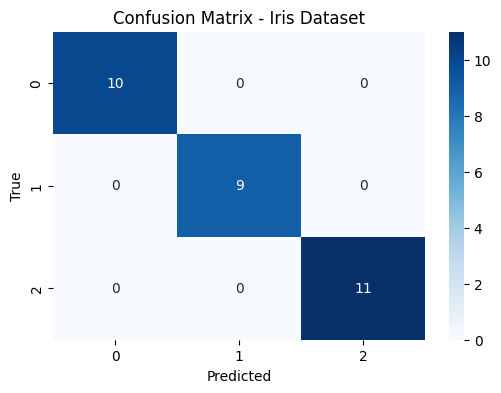

In [1]:
# Import required libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

# Load iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Split data
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model with default n_estimators=10
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)
print("Default (10 trees) score:", model.score(X_test, y_test))

# Fine-tune (try more trees)
for n in [30, 50, 100]:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    print(f"Score with {n} trees:", model.score(X_test, y_test))

# Confusion matrix for the best model
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Iris Dataset')
plt.show()
